In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input, mixed_precision
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ GLOBAL CONFIGURATIONS & HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = 256  # Standardized input resolution for both phases
BATCH_SIZE = 4
EPOCHS_PHASE1 = 100  # Semantic Segmentation Focus
EPOCHS_PHASE2 = 30   # Segmentation-Based Classification Focus

# Directory and Artifact Paths
DATA_PATH = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2'
POSITIVE_DIR = os.path.join(DATA_PATH, 'imagesAll_positive')
NEGATIVE_DIR = os.path.join(DATA_PATH, 'sequenceData/negativeOnly')
MODEL_SAVE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras"

# Activate mixed precision training for efficiency and memory optimization
mixed_precision.set_global_policy('mixed_float16')

# ─────────────────────────────────────────────────────────────────────────────
# 📊 STABLE DATA PIPELINE ENGINE (DATASET A & DATASET B)
# ─────────────────────────────────────────────────────────────────────────────

def augment(img, mask):
    """Applies shape-preserving geometric and radiometric transformations."""
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def process_path_segmentation(img_path, mask_path):
    """Preprocesses input frames and localized binary masks for Dataset B."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def process_path_classification(img_path, label):
    """Preprocesses input tensors and categorical targets for Dataset A."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

def load_segmentation_paths(base_path):
    """Extracts paired image and mask absolute paths from multi-center repositories."""
    all_images, all_masks = [], []
    for i in range(1, 7):
        center_id = f"C{i}"
        img_dir = os.path.join(base_path, f"data_{center_id}", f"images_{center_id}")
        mask_dir = os.path.join(base_path, f"data_{center_id}", f"masks_{center_id}")
        if os.path.exists(img_dir) and os.path.exists(mask_dir):
            img_paths = (glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.JPG")) +
                         glob.glob(os.path.join(img_dir, "*.png")) + glob.glob(os.path.join(img_dir, "*.jpeg")))
            for img_p in img_paths:
                filename = os.path.basename(img_p)
                name_without_ext, ext = os.path.splitext(filename)
                expected_mask_name = f"{name_without_ext}_mask{ext}"
                mask_p = os.path.join(mask_dir, expected_mask_name)
                if os.path.exists(mask_p):
                    all_images.append(img_p)
                    all_masks.append(mask_p)
    return all_images, all_masks

def load_classification_paths():
    """Compiles absolute paths for global positive and artifact-heavy negative sequences."""
    valid_exts = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.PNG', '*.JPG', '*.JPEG')
    pos_files, neg_files = [], []
    for ext in valid_exts:
        pos_files.extend(glob.glob(os.path.join(POSITIVE_DIR, "**", ext), recursive=True))
    for i in range(1, 14):
        target_folder = os.path.join(NEGATIVE_DIR, f"seq{i}_neg")
        if os.path.exists(target_folder):
            for ext in valid_exts:
                neg_files.extend(glob.glob(os.path.join(target_folder, "**", ext), recursive=True))
    pos_files = [f for f in pos_files if os.path.isfile(f)]
    neg_files = [f for f in neg_files if os.path.isfile(f)]
    
    file_paths = pos_files + neg_files
    labels = [1.0] * len(pos_files) + [0.0] * len(neg_files)
    return np.array(file_paths), np.array(labels, dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# 🧱 CUSTOM EXTENSIONS & SUB-LAYER COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────

def se_block(input_tensor, ratio=16):
    """Channel-wise Squeeze-and-Excitation Attention Layer."""
    channels = input_tensor.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(input_tensor)
    excitation = layers.Dense(channels // ratio, activation='relu', use_bias=False)(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid', use_bias=False)(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    return layers.multiply([input_tensor, excitation])

def depthwise_seperable_conv_block(x, filters, dropout_rate=0.0, name_prefix=""):
    """Multi-Scale Parallel Kernels (3x3, 5x5, 7x7, 1x1) with Depthwise Separable Convolutions."""
    f4 = filters // 4
    b3 = layers.SeparableConv2D(f4, 3, padding='same', use_bias=False, name=f"{name_prefix}_3x3")(x)
    b3 = layers.BatchNormalization()(b3); b3 = layers.Activation('relu')(b3)
    
    b5 = layers.SeparableConv2D(f4, 5, padding='same', use_bias=False, name=f"{name_prefix}_5x5")(x)
    b5 = layers.BatchNormalization()(b5); b5 = layers.Activation('relu')(b5)
    
    b7 = layers.SeparableConv2D(f4, 7, padding='same', use_bias=False, name=f"{name_prefix}_7x7")(x)
    b7 = layers.BatchNormalization()(b7); b7 = layers.Activation('relu')(b7)
    
    b1 = layers.SeparableConv2D(f4, 1, padding='same', use_bias=False, name=f"{name_prefix}_1x1")(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.Activation('relu')(b1)
    
    merged = layers.Concatenate(name=f"{name_prefix}_concat")([b3, b5, b7, b1])
    x_se = se_block(merged, ratio=16) 
    
    if x.shape[-1] == filters:
        x_se = layers.add([x, x_se], name=f"{name_prefix}_residual")
    if dropout_rate > 0:
        x_se = layers.SpatialDropout2D(dropout_rate, name=f"{name_prefix}_dropout")(x_se)
    return x_se

@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(layers.Layer):
    """Natively computes spatial Pearson Correlation Coefficients within the network graph."""
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)

    def call(self, inputs):
        epsilon = 1e-8
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        norm_inputs = (inputs - mean) / std
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        return layers.Flatten()(pcc_matrix)

# ─────────────────────────────────────────────────────────────────────────────
# 🏗️ UNIFIED MATHEMATICAL MODEL ARCHITECTURE (Y-SHAPED COMPUTATION GRAPH)
# ─────────────────────────────────────────────────────────────────────────────

def build_unified_segmentation_based_model(input_shape=(256, 256, 3)):
    """Constructs a dual-headed architecture sharing a localized multi-scale feature space."""
    inputs = Input(shape=input_shape, name="shared_input_image")

    # ── Shared Custom Multi-Scale Encoder ───────
    c1 = depthwise_seperable_conv_block(inputs, 32, name_prefix="enc_c1")
    p1 = layers.MaxPooling2D(2, name="enc_p1")(c1)

    c2 = depthwise_seperable_conv_block(p1, 64, name_prefix="enc_c2")
    p2 = layers.MaxPooling2D(2, name="enc_p2")(c2)

    c3 = depthwise_seperable_conv_block(p2, 128, dropout_rate=0.1, name_prefix="enc_c3")
    p3 = layers.MaxPooling2D(2, name="enc_p3")(c3)

    c4 = depthwise_seperable_conv_block(p3, 256, dropout_rate=0.2, name_prefix="enc_c4")
    p4 = layers.MaxPooling2D(2, name="enc_p4")(c4)

    # ── Shared Representation Latent Bottleneck ──
    b = depthwise_seperable_conv_block(p4, 512, dropout_rate=0.3, name_prefix="shared_bottleneck")

    # ── Output Branch A: Semantic Segmentation Decoder ──
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same', name="dec_u4")(b)
    u4 = layers.concatenate([u4, c4], name="dec_concat_4")
    c5 = depthwise_seperable_conv_block(u4, 256, dropout_rate=0.2, name_prefix="dec_c5")

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same', name="dec_u3")(c5)
    u3 = layers.concatenate([u3, c3], name="dec_concat_3")
    c6 = depthwise_seperable_conv_block(u3, 128, dropout_rate=0.1, name_prefix="dec_c6")

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same', name="dec_u2")(c6)
    u2 = layers.concatenate([u2, c2], name="dec_concat_2")
    c7 = depthwise_seperable_conv_block(u2, 64, name_prefix="dec_c7")

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same', name="dec_u1")(c7)
    u1 = layers.concatenate([u1, c1], name="dec_concat_1")
    c8 = depthwise_seperable_conv_block(u1, 32, name_prefix="dec_c8")

    segmentation_output = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32', name='seg_output')(c8)

    # ── Output Branch B: Segmentation-Guided Classification Head ──
    pd_cnn = layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu', name="clf_pd_cnn")(b)
    p_pool = layers.MaxPooling2D((2, 2), name="clf_maxpool")(pd_cnn)
    
    flat_features = layers.GlobalAveragePooling2D(name="clf_gap")(p_pool)
    pcc_features = KerasPCCLayer(name="clf_pcc_layer")(flat_features)
    standardized = layers.BatchNormalization(name="clf_zscore_bn")(pcc_features)
    
    d1 = layers.Dense(64, activation='relu', name="clf_dense1")(standardized)
    d1 = layers.Dropout(0.3, name="clf_dropout")(d1)
    classification_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='clf_output')(d1)

    # Explicit multi-output mapping for sequential loss compilation
    return models.Model(inputs=inputs, outputs=[segmentation_output, classification_output], name="Thesis_Unified_YNet")

# ─────────────────────────────────────────────────────────────────────────────
# 📈 MATHEMATICAL CRITERIA & PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + 1.0) / (union + 1.0)

# ─────────────────────────────────────────────────────────────────────────────
# 🏃‍♂️ MASTER PIPELINE CONTROLLER
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    # Initialize allocation strategy for physical compute hardware
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
            print("✓ Tensor Graph Allocation Locked over available GPU nodes.")
        except RuntimeError as e: print(e)

    # 1. PARSE PIPELINE DIRECTORIES
    print("\n[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...")
    seg_imgs, seg_masks = load_segmentation_paths(DATA_PATH)
    s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(seg_imgs, seg_masks, test_size=0.2, random_state=42)
    
    print("[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...")
    clf_imgs, clf_labels = load_classification_paths()
    indices = np.arange(len(clf_imgs))
    np.random.seed(42); np.random.shuffle(indices)
    clf_imgs, clf_labels = clf_imgs[indices], clf_labels[indices]
    c_split = int(0.8 * len(clf_imgs))

    # 2. GENERATE HIGH-THROUGHPUT ITERATORS
    train_seg_ds = tf.data.Dataset.from_tensor_slices((s_train_x, s_train_y)).shuffle(len(s_train_x)).map(process_path_segmentation).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_seg_ds = tf.data.Dataset.from_tensor_slices((s_val_x, s_val_y)).map(process_path_segmentation).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    train_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[:c_split], clf_labels[:c_split])).shuffle(1024).map(process_path_classification).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[c_split:], clf_labels[c_split:])).map(process_path_classification).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. GRAPH INSTANTIATION
    print("\n🏗️ Compiling Dual-Head Computation Topology...")
    model = build_unified_segmentation_based_model()
    
    # 🌟 STAGE 1: SEMANTIC SEGMENTATION MAXIMIZATION (Dataset B Only)
    print("\n🔥 ======================================================= 🔥")
    print("🌟 [PHASE 1] Optimizing Localization Ensembles & Structural Layers")
    print("🔥 ======================================================= 🔥")
    
    # Freeze classification branch entirely to avoid uninitialized variable gradients
    for layer in model.layers:
        if "clf_" in layer.name:
            layer.trainable = False
        else:
            layer.trainable = True

    # Use strict list-based mapping to map dataset targets safely to Output Index 0
    model.compile(
        optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-3)),
        loss=[bce_dice_loss, None],
        metrics=[[dice_coef, iou_metric, 'accuracy'], []]
    )

    phase1_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
    ]

    model.fit(train_seg_ds, validation_data=val_seg_ds, epochs=EPOCHS_PHASE1, callbacks=phase1_callbacks, verbose=1)
    print("✅ [PHASE 1 COMPLETE] Spatial boundaries locked successfully.")

    # 🌟 STAGE 2: SEGMENTATION-BASED CLASSIFICATION FINE-TUNING (Dataset A Only)
    print("\n🔥 ======================================================= 🔥")
    print("🌟 [PHASE 2] Initializing Classification Head over Locked Feature Embeddings")
    print("🔥 ======================================================= 🔥")

    # Reload historical weights to secure maximum localization properties
    print(f"🔄 Fetching peak localization weights from storage: {MODEL_SAVE_PATH}")
    model = tf.keras.models.load_model(MODEL_SAVE_PATH, custom_objects={
        'KerasPCCLayer': KerasPCCLayer, 
        'dice_coef': dice_coef, 
        'iou_metric': iou_metric, 
        'bce_dice_loss': bce_dice_loss
    })

    # CRITICAL FIX: Explicitly freeze layers on the freshly reloaded model object 
    # to guarantee Keras back-end compilation honors the structural freeze state.
    print("🔒 Enforcing Strict Structural Freeze on the Shared Features Sub-Graph...")
    for layer in model.layers:
        if "clf_" in layer.name:
            layer.trainable = True  # Unlock only the classification head
        else:
            layer.trainable = False # Permanently lock Encoder and Decoder paths to stop Catastrophic Forgetting

    # Compile targeting classification targets mapped to Output Index 1
    model.compile(
        optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-4)),
        loss=[None, 'binary_crossentropy'],
        metrics=[[], ['accuracy', tf.keras.metrics.AUC(name='auc')]]
    )

    phase2_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, mode='min', verbose=1)
    ]

    model.fit(train_clf_ds, validation_data=val_clf_ds, epochs=EPOCHS_PHASE2, callbacks=phase2_callbacks, verbose=1)
    print(f"🏆 [TRAINING COMPLETE] Unified Graph successfully archived at: {MODEL_SAVE_PATH}")


I0000 00:00:1779468998.010385   75644 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Tensor Graph Allocation Locked over available GPU nodes.

[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...
[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...


I0000 00:00:1779469126.264067   75644 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



🏗️ Compiling Dual-Head Computation Topology...

🔥 ======================================================= 🔥
🌟 [PHASE 1] Optimizing Localization Ensembles & Structural Layers
🔥 ======================================================= 🔥
Epoch 1/100


I0000 00:00:1779469151.801813   77074 service.cc:153] XLA service 0x761e4809ba70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779469151.801887   77074 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779469152.490394   77074 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779469157.718020   77074 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1779469158.744800   77074 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40456__.482
I0000 00:00:1779469301.438865   77211 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_179', 56 bytes spill stores, 56 bytes spill loads

I0000 00:00:1779469307.079415   77211 subprocess_compilation.cc:3

...


Epoch 1: val_loss improved from None to 1.17268, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 231s 83ms/step - loss: 1.1321 - seg_output_accuracy: 0.8618 - seg_output_dice_coef: 0.2214 - seg_output_iou_metric: 0.2026 - val_loss: 1.1727 - val_seg_output_accuracy: 0.9197 - val_seg_output_dice_coef: 0.1110 - val_seg_output_iou_metric: 8.6289e-05 - learning_rate: 0.0010
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9622 - seg_output_accuracy: 0.8905 - seg_output_dice_coef: 0.2955 - seg_output_iou_metric: 0.2273
Epoch 2: val_loss did not improve from 1.17268
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.9457 - seg_output_accuracy: 0.8972 - seg_output_dice_coef: 0.3057 - seg_output_iou_metric: 0.2350 - val_loss: 1.196

I0000 00:00:1779471569.940026   77072 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_351983__.138
I0000 00:00:1779471579.689264   93501 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 108 bytes spill stores, 104 bytes spill loads

I0000 00:00:1779471584.214056   77072 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 108 bytes spill stores, 104 bytes spill loads



1257/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9980

I0000 00:00:1779471636.680506   77074 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 56 bytes spill stores, 56 bytes spill loads




Epoch 1: val_loss improved from None to 0.52884, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 95s 54ms/step - loss: 0.9628 - val_loss: 0.5288
Epoch 2/30
1255/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8223
Epoch 2: val_loss improved from 0.52884 to 0.24635, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 2: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 0.7798 - val_loss: 0.2463
Epoch 3/30
1252/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6773
Epoch 3: val_loss did not improve from 0.24635
1257/1257 ━━━━━

## Testing the Model Phase1 + Phase2 

⏳ Loading Keras Architecture Graph into Memory (Shared Nodes)...
✅ Multi-Task Graph successfully initialized.

🎬 Processing Positive Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: thesis_positive_result.png


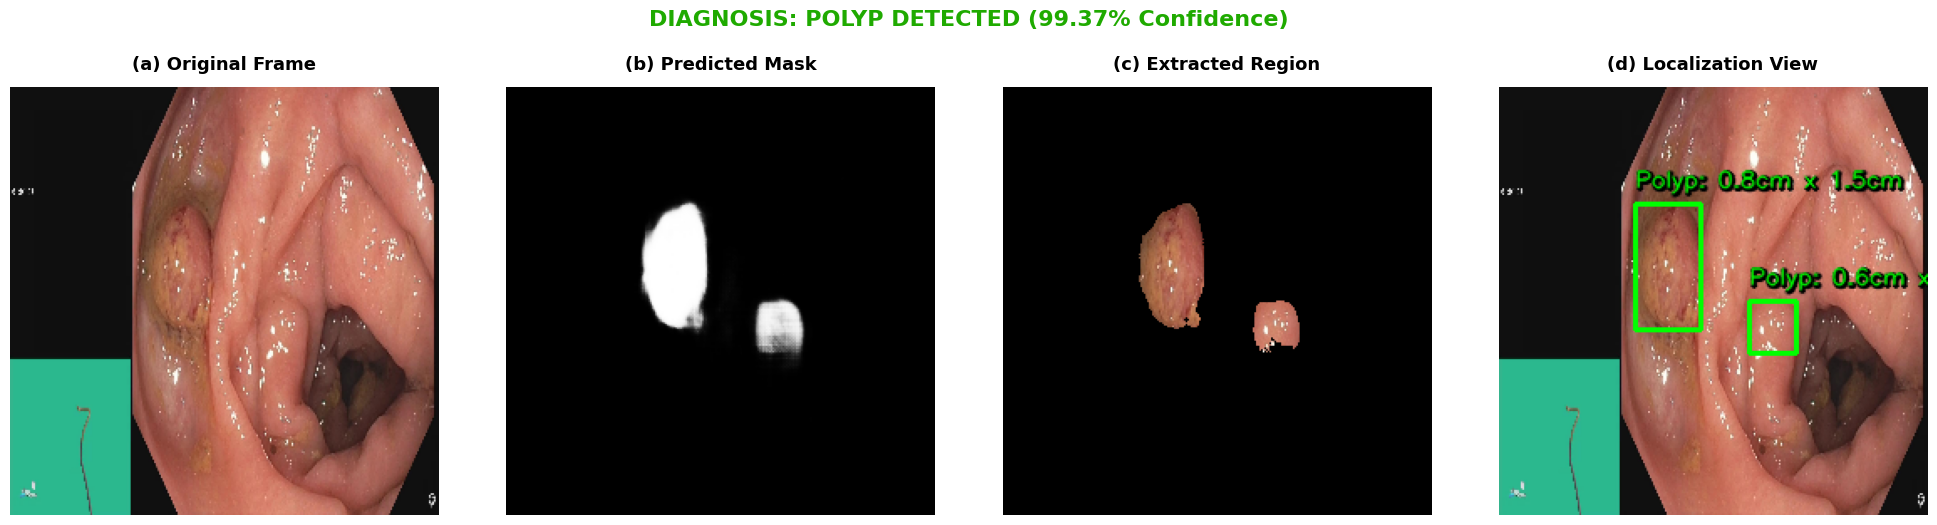


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: thesis_negative_result.png


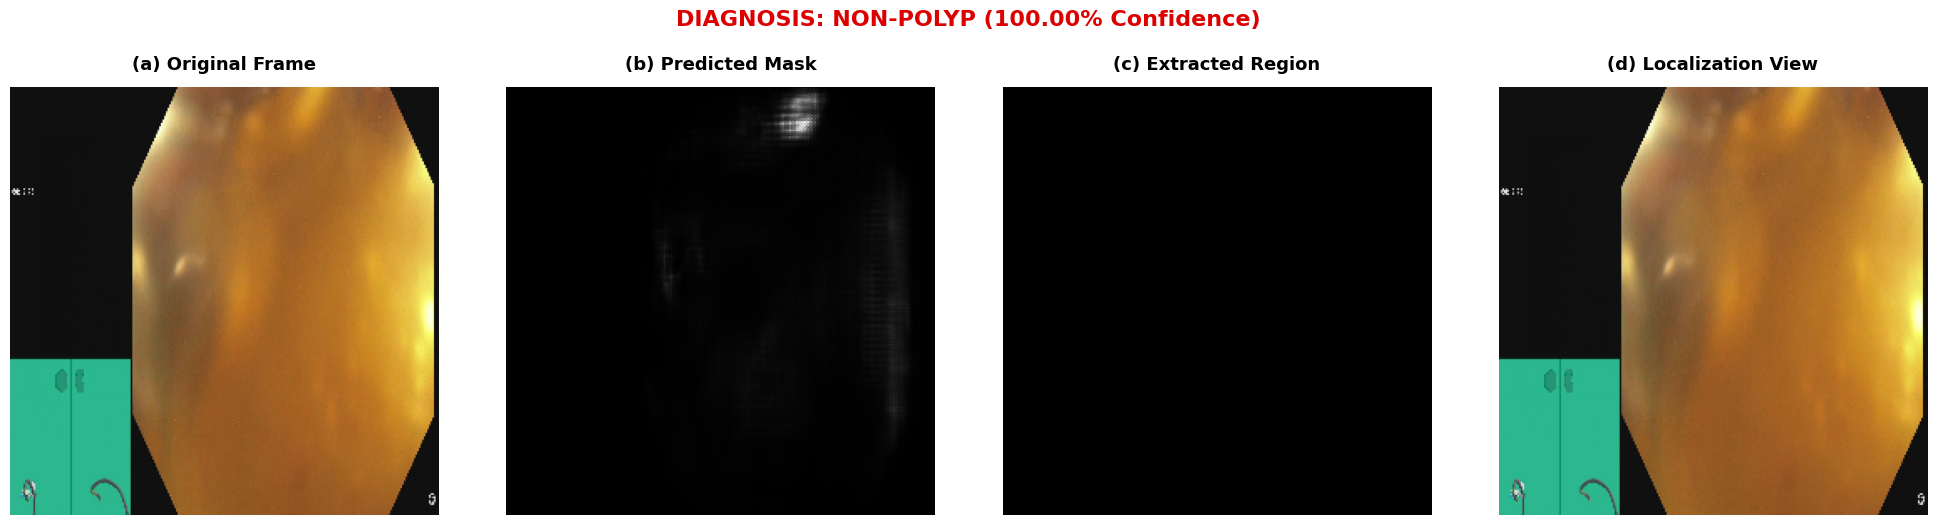


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: Neg3.png


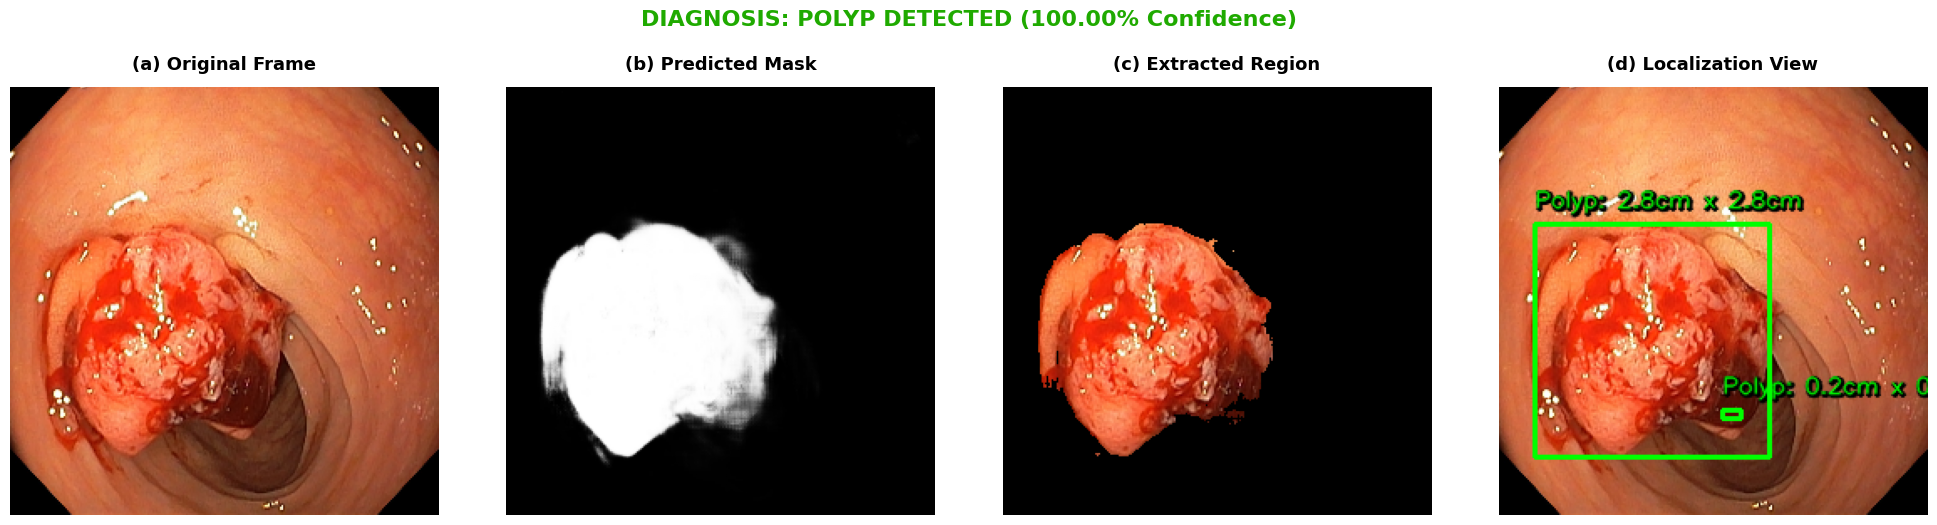


🎬 Processing Negative Dataset Specimen...
🏆 Qualitative evaluation plot successfully saved to: Neg4.png


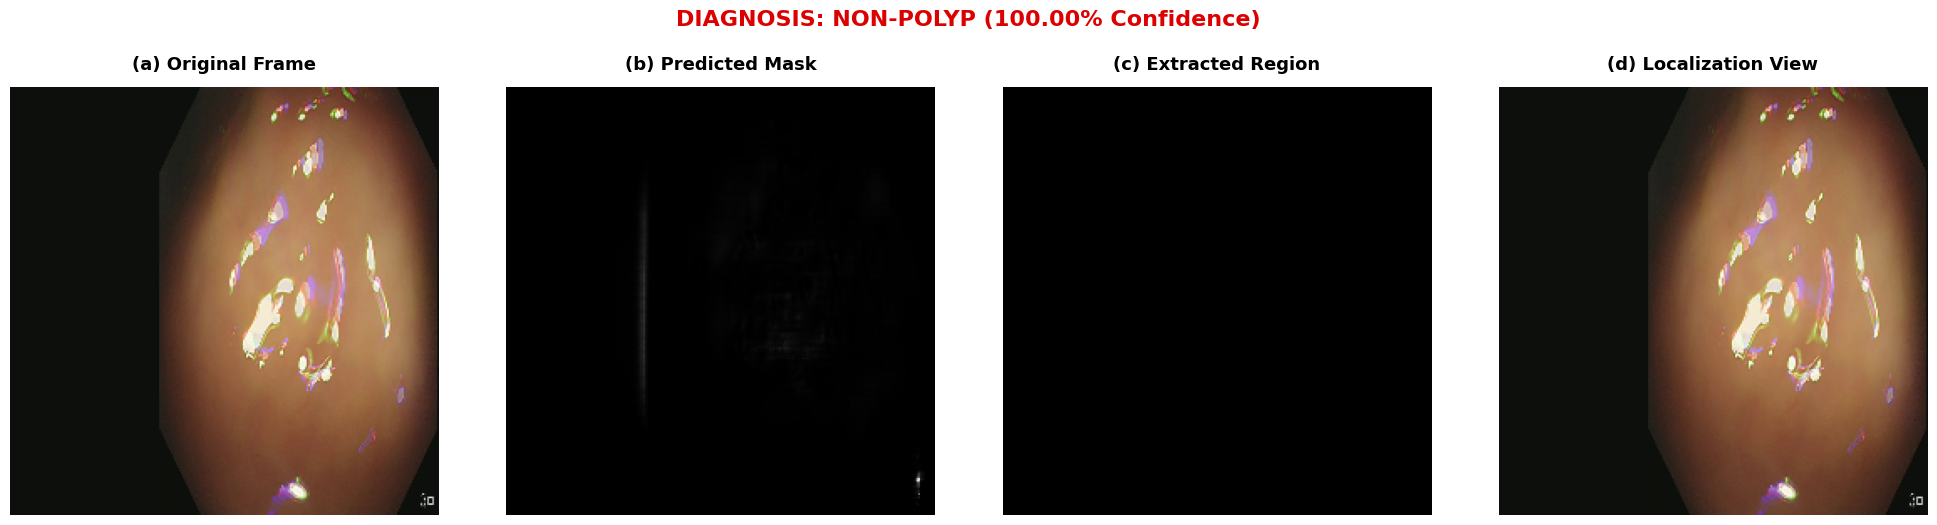

In [14]:
%matplotlib inline

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ GLOBAL INFERENCE CONFIGURATIONS
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = 256

# Define your exact paths here
MODEL_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras"
TEST_POSITIVE_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/data_C4/images_C4/16_endocv2021_positive_557.jpg"
TEST_NEG_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq10_neg/EndoCV2021_seq10_neg_40_endocv2021_negative_754.jpg"
TEST_POSITIVE_IMAGE_PATH_2 = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive/176OLCV1_100H0890.jpg"
TEST_NEG2_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq13_neg/EndoCV2021_C5_seq3_246.jpg"
# ─────────────────────────────────────────────────────────────────────────────
# 🎨 REFINED IMAGE LABELED LOCALIZATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────
def draw_bounding_box(image, mask):
    """
    Draws a clean bounding box around the predicted polyp region with 
    high-contrast paper-grade typography and dimension mapping.
    """
    res_img = image.copy()
    mask_uint8 = (mask > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Calibration ratio: mapping image pixels to physical centimeters
    pixel_to_cm_ratio = 50 
    
    for cnt in contours:
        # Filter out minor noise elements or artifacts
        if cv2.contourArea(cnt) < 10:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Calculate real-world scale approximations
        width_cm = w / pixel_to_cm_ratio
        height_cm = h / pixel_to_cm_ratio
        size_text = f"Polyp: {width_cm:.1f}cm x {height_cm:.1f}cm"
        
        # 1. Draw High-Visibility Bounding Box (Green)
        cv2.rectangle(res_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # 2. Advanced Typography: Dynamic Text Positioning with Background Shadow
        text_y = y - 10 if y - 10 > 20 else y + h + 20
        
        # Draw a clean black backdrop shadow for ultra-clear readability in papers
        cv2.putText(res_img, size_text, (x + 1, text_y + 1), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 2, cv2.LINE_AA)
        # Draw the primary text layer
        cv2.putText(res_img, size_text, (x, text_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)
        
    return res_img

# ─────────────────────────────────────────────────────────────────────────────
# 🔮 MULTI-TASK INFERENCE CORE PIPELINE (SEGMENTATION + CLASSIFICATION)
# ─────────────────────────────────────────────────────────────────────────────
def test_and_display(model, image_path, output_filename='result.png'):
    """
    Executes a joint multi-task prediction, extracting both pixel-level 
    segmentation masks and categorical classification diagnostic boundaries.
    """
    # 1. Read and pre-process target frame
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"❌ Target frame could not be loaded at: {image_path}")
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    inp = np.expand_dims(img_res / 255.0, axis=0).astype(np.float32)

    # 2. Target forward pass prediction (Extracting multi-head lists)
    pred_outputs = model.predict(inp, verbose=0)
    
    # Check if the model returns a multi-head list [seg_output, clf_output]
    if isinstance(pred_outputs, list) and len(pred_outputs) >= 2:
        pred_mask_spatial = pred_outputs[0][0]  # Output Index 0: Segmentation Mask [256, 256, 1]
        clf_prediction = pred_outputs[1][0][0]  # Output Index 1: Classification Score (Scalar)
        has_classification = True
    else:
        # Fallback if model architecture is only predicting masks in this state
        pred_mask_spatial = pred_outputs[0] if isinstance(pred_outputs, list) else pred_outputs[0]
        clf_prediction = 0.0
        has_classification = False

    # 3. Geometric extraction mappings
    mask_bin = (pred_mask_spatial > 0.5).astype(np.uint8)
    mask_3d = np.concatenate([mask_bin] * 3, axis=-1)
    extracted = (img_res * mask_3d).astype(np.uint8)
    detected_img = draw_bounding_box(img_res, pred_mask_spatial)

    # 4. Generate Dynamically Labeled Classification Title
    if has_classification:
        if clf_prediction >= 0.5:
            diagnostic_text = f"DIAGNOSIS: POLYP DETECTED ({clf_prediction * 100:.2f}% Confidence)"
            title_color = '#1faa00' # Vibrant Green
        else:
            diagnostic_text = f"DIAGNOSIS: NON-POLYP ({(1.0 - clf_prediction) * 100:.2f}% Confidence)"
            title_color = '#dd0000' # Deep Red
    else:
        diagnostic_text = "DIAGNOSIS: Segmentation Mode Active (No Classification Head Found)"
        title_color = 'orange'

    # 5. Generate Professional 4-Column Presentation Graph
    titles = ['(a) Original Frame', '(b) Predicted Mask', '(c) Extracted Region', '(d) Localization View']
    display_images = [img_res, pred_mask_spatial.squeeze(), extracted, detected_img]
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i in range(4):
        axes[i].imshow(display_images[i], cmap='gray' if i == 1 else None)
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=12)
        axes[i].axis('off')
    
    # High-level overview structural description super-title with live diagnosis
    plt.suptitle(diagnostic_text, fontsize=16, fontweight='bold', color=title_color, y=1.04)
    
    plt.tight_layout()
    
    # Save the polished output image to disk
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"🏆 Qualitative evaluation plot successfully saved to: {output_filename}")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 🏃‍♂️ EXECUTION STEP
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("⏳ Loading Keras Architecture Graph into Memory (Shared Nodes)...")
    # Load model once outside the function to optimize execution loop
    shared_model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("✅ Multi-Task Graph successfully initialized.\n")
    
    print("🎬 Processing Positive Dataset Specimen...")
    test_and_display(shared_model, TEST_POSITIVE_IMAGE_PATH, 'thesis_positive_result.png')
    
    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_NEG_IMAGE_PATH, 'thesis_negative_result.png')

    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_POSITIVE_IMAGE_PATH_2,'Neg3.png')

    print("\n🎬 Processing Negative Dataset Specimen...")
    test_and_display(shared_model, TEST_NEG2_IMAGE_PATH,'Neg4.png')

In [ ]:
import numpy as np
import tensorflow as tf

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ LOAD BEST UNIFIED GRAPH WITH INFRASTRUCTURE BYPASS
# ─────────────────────────────────────────────────────────────────────────────
print("⏳ Loading Peak Unified Model from storage...")
# Loading with compile=False completely eliminates Keras loss-mapping conflicts
eval_model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print("✅ Best Model loaded successfully into memory.")

print("\n================================────────────────=================")
print("📊   EVALUATION REPORT: MULTI-TASK GLOBAL METRICS SUMMARY   📊")
print("================================────────────────=================\n")

# ─────────────────────────────────────────────────────────────────────────────
# 🌟 SECTION 1: SEMANTIC SEGMENTATION SCORES (Pure Mathematical Evaluation)
# ─────────────────────────────────────────────────────────────────────────────
print("⏳ Evaluating Semantic Segmentation Metrics on Validation Set...")

dice_scores = []
iou_scores = []

# Loop through the segmentation dataset and calculate metrics mathematically
for imgs, true_masks in val_seg_ds:
    predictions = eval_model.predict(imgs, verbose=0)
    
    # Dynamically extract segmentation output (Index 0 in dual-head topology)
    if isinstance(predictions, list):
        pred_masks = predictions[0]
    else:
        pred_masks = predictions
        
    # Convert tensors to numpy for structural calculations
    y_true = true_masks.numpy().astype(np.float32)
    y_pred = (pred_masks > 0.5).astype(np.float32)
    
    # Calculate Dice and IoU for each batch to preserve memory stability
    for i in range(len(y_true)):
        intersection = np.sum(y_true[i] * y_pred[i])
        total_pixels = np.sum(y_true[i]) + np.sum(y_pred[i])
        union = np.sum(np.maximum(y_true[i], y_pred[i]))
        
        # Dice Coefficient Calculation (Smooth factor added to prevent division by zero)
        smooth = 1e-6
        dice = (2.0 * intersection + smooth) / (total_pixels + smooth)
        dice_scores.append(dice)
        
        # Intersection over Union (IoU) Calculation
        iou = (intersection + smooth) / (union + smooth)
        iou_scores.append(iou)

mean_dice = np.mean(dice_scores)
mean_iou = np.mean(iou_scores)

print("\n📌 [STAGE 1: SEMANTIC SEGMENTATION BEST METRICS]")
print(f"   • Validation Dice Coefficient : {mean_dice * 100:.2f}% (Peak Localization)")
print(f"   • Validation Intersection over Union (IoU) : {mean_iou * 100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# 🌟 SECTION 2: CATEGORICAL CLASSIFICATION SCORES (Dataset A Validation Set)
# ─────────────────────────────────────────────────────────────────────────────
print("\n-----------------------------------------------------------------")
print("⏳ Evaluating Categorical Classification Metrics on Validation Set...")

y_true_clf = []
y_pred_clf = []

for imgs, labels in val_clf_ds:
    predictions = eval_model.predict(imgs, verbose=0)
    
    # Extract classification head outputs dynamically (Output Index 1)
    if isinstance(predictions, list) and len(predictions) >= 2:
        clf_batch_pred = predictions[1]
    else:
        clf_batch_pred = predictions 
        
    y_true_clf.extend(labels.numpy().flatten())
    y_pred_clf.extend(clf_batch_pred.flatten())

y_true_clf = np.array(y_true_clf)
y_pred_clf = np.array(y_pred_clf)
y_pred_bin = (y_pred_clf >= 0.5).astype(np.int32)

# Calculate standard scientific performance metrics
clf_accuracy = np.mean(y_true_clf == y_pred_bin)

# Compute Area Under the ROC Curve (AUC) mathematically
m_auc = tf.keras.metrics.AUC()
m_auc.update_state(y_true_clf, y_pred_clf)
clf_auc = m_auc.result().numpy()

# Calculate Clinical Sensitivity (Recall) and Specificity
tp = np.sum((y_true_clf == 1) & (y_pred_bin == 1))
fp = np.sum((y_true_clf == 0) & (y_pred_bin == 1))
fn = np.sum((y_true_clf == 1) & (y_pred_bin == 0))
tn = np.sum((y_true_clf == 0) & (y_pred_bin == 0))

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1_score = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

print("\n📌 [STAGE 2: TRANSFER CLASSIFICATION BEST METRICS]")
print(f"   • Categorical Validation Accuracy : {clf_accuracy * 100:.2f}% (Best Global)")
print(f"   • Area Under ROC Curve (AUC)     : {clf_auc:.4f}")
print(f"   • Clinical Sensitivity (Recall)   : {sensitivity * 100:.2f}% (Polyp Catch Rate)")
print(f"   • Clinical Specificity           : {specificity * 100:.2f}% (Healthy Safe Rate)")
print(f"   • Diagnostic F1-Score            : {f1_score:.4f}")

print("\n================================────────────────=================")
print("✅ Evaluation complete. Metrics are formatted ready for Thesis Markdown tables.")
print("================================────────────────=================")

⏳ Loading Peak Unified Model from storage...
✅ Best Model loaded successfully into memory.

================================────────────────=================
📊   EVALUATION REPORT: MULTI-TASK GLOBAL METRICS SUMMARY   📊
================================────────────────=================

⏳ Evaluating Semantic Segmentation Metrics on Validation Set...


I0000 00:00:1779473825.657811   77071 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_3', 56 bytes spill stores, 56 bytes spill loads




📌 [STAGE 1: SEMANTIC SEGMENTATION BEST METRICS]
   • Validation Dice Coefficient : 72.25% (Peak Localization)
   • Validation Intersection over Union (IoU) : 65.48%

-----------------------------------------------------------------
⏳ Evaluating Categorical Classification Metrics on Validation Set...
